# Суммаризация статей Habr

Два блока моделей:
- **Без эмбеддингов** — генеративные seq2seq модели (абстрактивная суммаризация)
- **С эмбеддингами** — экстрактивная суммаризация через embedding-модели

Метрики: ROUGE-L, BERTScore, METEOR, Keyword Coverage, Compression Ratio

## 0. Установка зависимостей

In [30]:
!pip install transformers torch sentencepiece rouge-score bert-score nltk accelerate sentencepiece protobuf seaborn -q

In [2]:
!pip install huggingface_hub

In [ ]:
!hf auth login --token YOUR_TOKEN

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Error: Invalid user token.
Set HF_DEBUG=1 as environment variable for full traceback.


In [ ]:
!huggingface-cli download bert-base-multilingual-cased
# почему-то не качалась


Hint: A new version of huggingface_hub (1.14.0) is available! You are using version 1.13.0.
To update, run: hf update
Hint: `hf` is already installed! Use it directly.

Hint: Examples:
  hf auth login
  hf download unsloth/gemma-4-31B-it-GGUF
  hf upload my-cool-model . .
  hf models ls --search "gemma"
  hf repos ls --format json
  hf jobs run python:3.12 python -c 'print("Hello!")'
  hf --help



## 1. Импорты и загрузка данных

In [ ]:
import re
import ast
import warnings
import pandas as pd
import torch
import torch.nn.functional as F
import nltk

from transformers import (
    AutoTokenizer, AutoModel,
    AutoModelForSeq2SeqLM,
)
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize

nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

/Users/ni.korolev/Projects/learning/hse/habr_ai_summarizer/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [ ]:
DATA_PATH = "../local/habr.csv" # поменяйте на нужный путь

data = pd.read_csv(DATA_PATH, encoding='utf-8')
data.dropna(subset=['text'], inplace=True)

def safe_eval(val):
    try:
        return ast.literal_eval(val) if isinstance(val, str) else (val if isinstance(val, list) else [])
    except:  # noqa: E722
        return []

data['keywords'] = data['keywords'].apply(safe_eval)
data['hubs'] = data['hubs'].apply(safe_eval)

print(f"Всего статей: {len(data)}")
data[['title', 'text', 'keywords']].head(3)

Всего статей: 151554


,title,text,keywords
0,Удачный проект с площадки Kickstarter – лампа ...,12 марта 2014 года на Kickstarter стартовала к...,"[даджет, даджеты, kickstarter, bluetooth, ламп..."
1,Porsche построила первую электросолнечную коло...,Автопроизводитель Porscheобъявил об окончании ...,"[Porsche, Mission E]"
2,С чего начинается рак: медики проследили разви...,Медики из Бостонского детского госпиталясмогли...,"[данио-рерио, рак, раковая опухоль, поля канце..."


In [3]:
# для экспериментов — берём 50 статей разной длины
data['text_len'] = data['text'].str.len()

short  = data[data['text_len'] < 3000].sample(min(15, len(data[data['text_len'] < 3000])), random_state=42)
medium = data[(data['text_len'] >= 3000) & (data['text_len'] < 10000)].sample(min(20, len(data[(data['text_len'] >= 3000) & (data['text_len'] < 10000)])), random_state=42)
long_  = data[data['text_len'] >= 10000].sample(min(15, len(data[data['text_len'] >= 10000])), random_state=42)

sample = pd.concat([short, medium, long_]).reset_index(drop=True)
print(f"Выборка: {len(sample)} статей")
print(sample['text_len'].describe())

Выборка: 50 статей
count       50.000000
mean      8888.960000
std       9220.162412
min        428.000000
25%       2596.250000
50%       4911.500000
75%      10752.250000
max      36536.000000
Name: text_len, dtype: float64


## 2. Метрики

In [ ]:
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

def compute_rouge_l(summary: str, reference: str) -> float:
    """ROUGE-L между саммари и заголовком/референсом."""
    if not summary or not reference:
        return 0.0
    return rouge.score(reference, summary)['rougeL'].fmeasure


def compute_meteor(summary: str, reference: str) -> float:
    """METEOR."""
    if not summary or not reference:
        return 0.0
    ref_tokens  = word_tokenize(reference.lower())
    hyp_tokens  = word_tokenize(summary.lower())
    return meteor_score([ref_tokens], hyp_tokens)


def compute_keyword_coverage(summary: str, keywords: list) -> float:
    """Доля keywords из датасета, которые попали в саммари."""
    if not keywords or not summary:
        return 0.0
    summary_lower = summary.lower()
    hits = sum(1 for kw in keywords if kw.lower() in summary_lower)
    return hits / len(keywords)


def compute_compression_ratio(summary: str, original: str) -> float:
    """Длина саммари / длина оригинала."""
    if not original:
        return 0.0
    return len(summary) / len(original)


def evaluate_summaries(summaries: list, texts: list, titles: list, keywords_list: list) -> pd.DataFrame:
    """Считает все метрики для списка саммари."""
    results = []
    for summary, text, title, keywords in zip(summaries, texts, titles, keywords_list):
        results.append({
            'rouge_l': compute_rouge_l(summary, title),
            'meteor': compute_meteor(summary, title),
            'keyword_coverage': compute_keyword_coverage(summary, keywords),
            'compression_ratio': compute_compression_ratio(summary, text),
        })
    df = pd.DataFrame(results)

    return df

## 3. Модели без эмбеддингов

### 3.1 MBART обученная на русских газетах

In [16]:
import torch
from transformers import MBartForConditionalGeneration, MBartTokenizer

MBART_MODEL_ID = "IlyaGusev/mbart_ru_sum_gazeta"

ru_gazeta_model = MBartForConditionalGeneration.from_pretrained(
    MBART_MODEL_ID, ignore_mismatched_sizes=True
)

state = ru_gazeta_model.state_dict()
shared = state["model.shared.weight"]
state["model.encoder.embed_tokens.weight"] = shared
state["model.decoder.embed_tokens.weight"] = shared
ru_gazeta_model.load_state_dict(state)

mbart_tok = MBartTokenizer.from_pretrained(MBART_MODEL_ID, use_fast=True)
ru_gazeta_model.eval()

def summarize_ru_gazeta(text: str, max_input: int = 600, max_output: int = 120) -> str:
    inputs = mbart_tok(
        text,
        return_tensors="pt",
        max_length=max_input,
        truncation=True,
    )
    with torch.no_grad():
        output = ru_gazeta_model.generate(
            **inputs,
            max_length=max_output,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            forced_bos_token_id=mbart_tok.lang_code_to_id["ru_RU"],
        )
    return mbart_tok.decode(output[0], skip_special_tokens=True)

# Тест
test_text = sample['text'].iloc[0]
print("Саммари:", summarize_ru_gazeta(test_text))

Loading weights: 100%|██████████| 517/517 [00:00<00:00, 7563.45it/s]
[transformers] MBartForConditionalGeneration LOAD REPORT from: IlyaGusev/mbart_ru_sum_gazeta
Key                               | Status  | 
----------------------------------+---------+-
model.encoder.embed_tokens.weight | MISSING | 
model.decoder.embed_tokens.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Саммари: Роскомнадзор заявил, что 80% операторов самостоятельно направляют в ведомство уведомления об утечках персональных данных в установленные законом сроки, а 20% приходится напоминать о передаче информации об инциденте. По словам замглавы ведомства Милоша Вагнера, это может помочь избежать ответственности по статье о повторном правонарушении.


### 3.2 mT5 обученная на XLSum (мультиязычная)

In [ ]:
def WHITESPACE_HANDLER(k):
    return re.sub(r'\s+', ' ', re.sub(r'\n+', ' ', k.strip()))

print("Загружаем mT5-XLSum...")
mt5_tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/mT5_multilingual_XLSum")
mt5_model     = AutoModelForSeq2SeqLM.from_pretrained("csebuetnlp/mT5_multilingual_XLSum").to(DEVICE)
mt5_model.eval()

LANG_TOKEN = "<ru>"

def summarize_mt5(text: str, max_input: int = 512, max_output: int = 120) -> str:
    clean_text = WHITESPACE_HANDLER(text)
    input_ids  = mt5_tokenizer(
        [LANG_TOKEN + clean_text],
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_input
    ).input_ids.to(DEVICE)

    with torch.no_grad():
        output = mt5_model.generate(
            input_ids,
            max_length=max_output,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    return mt5_tokenizer.decode(output[0], skip_special_tokens=True)

print("Саммари:", summarize_mt5(test_text))

Загружаем mT5-XLSum...


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 65363.39it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Саммари: Роскомнадзор заявил, что 80% операторов самостоятельно направляют в ведомство уведомления об утечках персональных данных в установленные законом сроки.


### 3.3 MBART от фейсбука (мультиязычная)

In [15]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

print("Загружаем mBART-large-cc25...")
mbart_tokenizer = MBart50TokenizerFast.from_pretrained(
    "facebook/mbart-large-50",
    src_lang="ru_RU", tgt_lang="ru_RU"
)
mbart_model = MBartForConditionalGeneration.from_pretrained("facebook/mbart-large-50").to(DEVICE)
mbart_model.eval()

def summarize_mbart(text: str, max_input: int = 512, max_output: int = 120) -> str:
    inputs = mbart_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input
    ).to(DEVICE)

    with torch.no_grad():
        output = mbart_model.generate(
            **inputs,
            forced_bos_token_id=mbart_tokenizer.lang_code_to_id["ru_RU"],
            max_length=max_output,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    return mbart_tokenizer.decode(output[0], skip_special_tokens=True)

print("Саммари:", summarize_mbart(test_text))

Загружаем mBART-large-cc25...


Loading weights: 100%|██████████| 519/519 [00:00<00:00, 72214.83it/s]


Саммари: Роскомнадзор заявил, что 80% операторов самостоятельно направляют в ведомство уведомления об утечках персональных данных в установленные законом сроки


## 4. Экстрактивная + абстрактивная суммаризация

### 4.1 mBART + E5

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer

E5_MODEL_ID = "intfloat/multilingual-e5-large"

e5_tok = AutoTokenizer.from_pretrained(E5_MODEL_ID)
e5_model = AutoModel.from_pretrained(E5_MODEL_ID)
e5_model.eval()


def _e5_embed(texts: list, prefix: str) -> torch.Tensor:
    batch = e5_tok(
        [prefix + t for t in texts],
        max_length=512, padding=True,
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        out = e5_model(**batch)
    mask = batch["attention_mask"].unsqueeze(-1).float()
    emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
    return F.normalize(emb, p=2, dim=1)


def _select_sentences(text: str, title: str, top_k: int = 5) -> str:
    """E5: выбирает top_k предложений наиболее близких к заголовку."""
    import re
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.split()) >= 5]
    if len(sentences) <= top_k:
        return text

    sent_emb = _e5_embed(sentences, prefix="passage: ")
    query_emb = _e5_embed([title], prefix="query: ")
    scores = (sent_emb @ query_emb.T).squeeze(-1)

    top_idx = sorted(torch.topk(scores, k=top_k).indices.tolist())
    return " ".join(sentences[i] for i in top_idx)


def summarize_e5_mbart(
    text: str,
    title: str = "",
    top_k: int = 5,
    max_input: int = 600,
    max_output: int = 120,
) -> str:
    """
    1. E5 выбирает top_k самых релевантных предложений (extractive)
    2. mBART генерирует суммари по этим предложениям (abstractive)
    """
    compressed = _select_sentences(text, title=title or text[:80], top_k=top_k)
    return summarize_mbart(compressed, max_input=max_input, max_output=max_output)


test_title = sample['title'].iloc[0]
test_text  = sample['text'].iloc[0]

print(summarize_e5_mbart(test_text, title=test_title))

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7297.23it/s]


Об этом рассказал заместитель руководителя Роскомнадзора Милош Вагнер в рамках пленарной дискуссии BIS Summit 2023. Информационная служба Хабра находится на мероприятии.В рамках пленарного заседания Милош Ваганер рассказал, что передача информации об инциденте может помочь оператору избежать ответственности по статье о повторном правонарушении


### 4.2 E5 + mBART на RU-gazeta

In [51]:
def summarize_e5_ru_gazeta(
    text: str,
    title: str = "",
    top_k: int = 5,
    max_input: int = 600,
    max_output: int = 120,
) -> str:
    """
    1. E5 выбирает top_k самых релевантных предложений
    2. ru_gazeta (mBART) генерирует суммари по ним
    """
    compressed = _select_sentences(text, title=title or text[:80], top_k=top_k)
    return summarize_ru_gazeta(compressed, max_input=max_input, max_output=max_output)


# Тест
test_title = sample['title'].iloc[0]
test_text  = sample['text'].iloc[0]

print(summarize_e5_ru_gazeta(test_text, title=test_title))

В рамках пленарной дискуссии BIS Summit 2023 заместитель руководителя Роскомнадзора Милош Вагнер рассказал, что передача информации об утечке информации об инциденте может помочь оператору избежать ответственности по статье о повторном правонарушении. Он также рассказал о поправках в КоАП, предусматривающих увеличение штрафов за утечки, вплоть до оборотных за повторные.


### 5. Инференс на тестовой выборке

In [23]:
from tqdm.auto import tqdm

texts = sample['text'].tolist()
titles = sample['title'].tolist()
keywords = sample['keywords'].tolist()

ru_gazeta_summaries  = []
mt5_summaries   = []
mbart_summaries = []
e5_summarizes = []

for text in tqdm(texts, desc="ru-gazeta"):
    ru_gazeta_summaries.append(summarize_ru_gazeta(text))

for text in tqdm(texts, desc="mT5-XLSum"):
    mt5_summaries.append(summarize_mt5(text))

for text in tqdm(texts, desc="mBART"):
    mbart_summaries.append(summarize_mbart(text))

for text in tqdm(texts, desc="E5+mBART"):
    e5_summarizes.append(summarize_e5_mbart(text))

E5+mBART: 100%|██████████| 50/50 [17:41<00:00, 21.23s/it]


In [52]:
e5_ru_gazeta_summarizes = []

for text in tqdm(texts, desc="E5+ru-gazeta"):
    e5_ru_gazeta_summarizes.append(summarize_e5_ru_gazeta(text))

E5+ru-gazeta: 100%|██████████| 50/50 [14:08<00:00, 16.96s/it]


In [60]:
e5_ru_gazeta_summarizes_top_30 = []
e5_summarizes_top_30 = []

for text in tqdm(texts, desc="E5+ru-gazeta-top-30"):
    e5_ru_gazeta_summarizes_top_30.append(summarize_e5_ru_gazeta(text, top_k=30))

for text in tqdm(texts, desc="E5+mBART-top-30"):
    e5_summarizes_top_30.append(summarize_e5_mbart(text, top_k=30))

E5+mBART-top-30: 100%|██████████| 50/50 [17:56<00:00, 21.53s/it]


## 5. Оценка всех моделей

In [61]:
model_summaries = {
    "ru-gazeta": ru_gazeta_summaries,
    "mT5-XLSum": mt5_summaries,
    "mBART-large-50": mbart_summaries,
    "e5-mBART": e5_summarizes,
    "e5-ru-gazeta": e5_ru_gazeta_summarizes,
    "e5-mBART-top-30": e5_summarizes_top_30,
    "e5-ru-gazeta-top-30": e5_ru_gazeta_summarizes_top_30,
}

all_metrics = {}
for model_name, summaries in model_summaries.items():
    print(f"Считаем метрики для {model_name}...")
    metrics_df = evaluate_summaries(summaries, texts, titles, keywords)
    all_metrics[model_name] = metrics_df

Считаем метрики для ru-gazeta...
Считаем метрики для mT5-XLSum...
Считаем метрики для mBART-large-50...
Считаем метрики для e5-mBART...
Считаем метрики для e5-ru-gazeta...
Считаем метрики для e5-mBART-top-30...
Считаем метрики для e5-ru-gazeta-top-30...


## 6. Сводная таблица результатов

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

METRICS = ['rouge_l', 'meteor', 'keyword_coverage', 'compression_ratio']

summary_rows = []
for model_name, df in all_metrics.items():
    row = {'model': model_name, 'type': 'generative' if model_name in ['ru-gazeta', 'mT5-XLSum', 'mBART-large-50'] else 'extractive'}
    for metric in METRICS:
        row[metric] = df[metric].mean()
    summary_rows.append(row)

results = pd.DataFrame(summary_rows).set_index('model')
results = results.round(4)

print("СВОДНАЯ ТАБЛИЦА МЕТРИК (среднее по выборке)")
print(results.to_string())

СВОДНАЯ ТАБЛИЦА МЕТРИК (среднее по выборке)
                           type  rouge_l  meteor  keyword_coverage  compression_ratio
model                                                                                
ru-gazeta            generative   0.3476  0.1955            0.3121             0.0694
mT5-XLSum            generative   0.2807  0.1147            0.1759             0.0312
mBART-large-50       generative   0.1971  0.1543            0.3802             0.1128
e5-mBART             extractive   0.2197  0.1454            0.3274             0.1056
e5-ru-gazeta         extractive   0.2378  0.1515            0.2184             0.0619
e5-mBART-top-30      extractive   0.2378  0.1567            0.3976             0.1161
e5-ru-gazeta-top-30  extractive   0.3231  0.1954            0.2712             0.0688


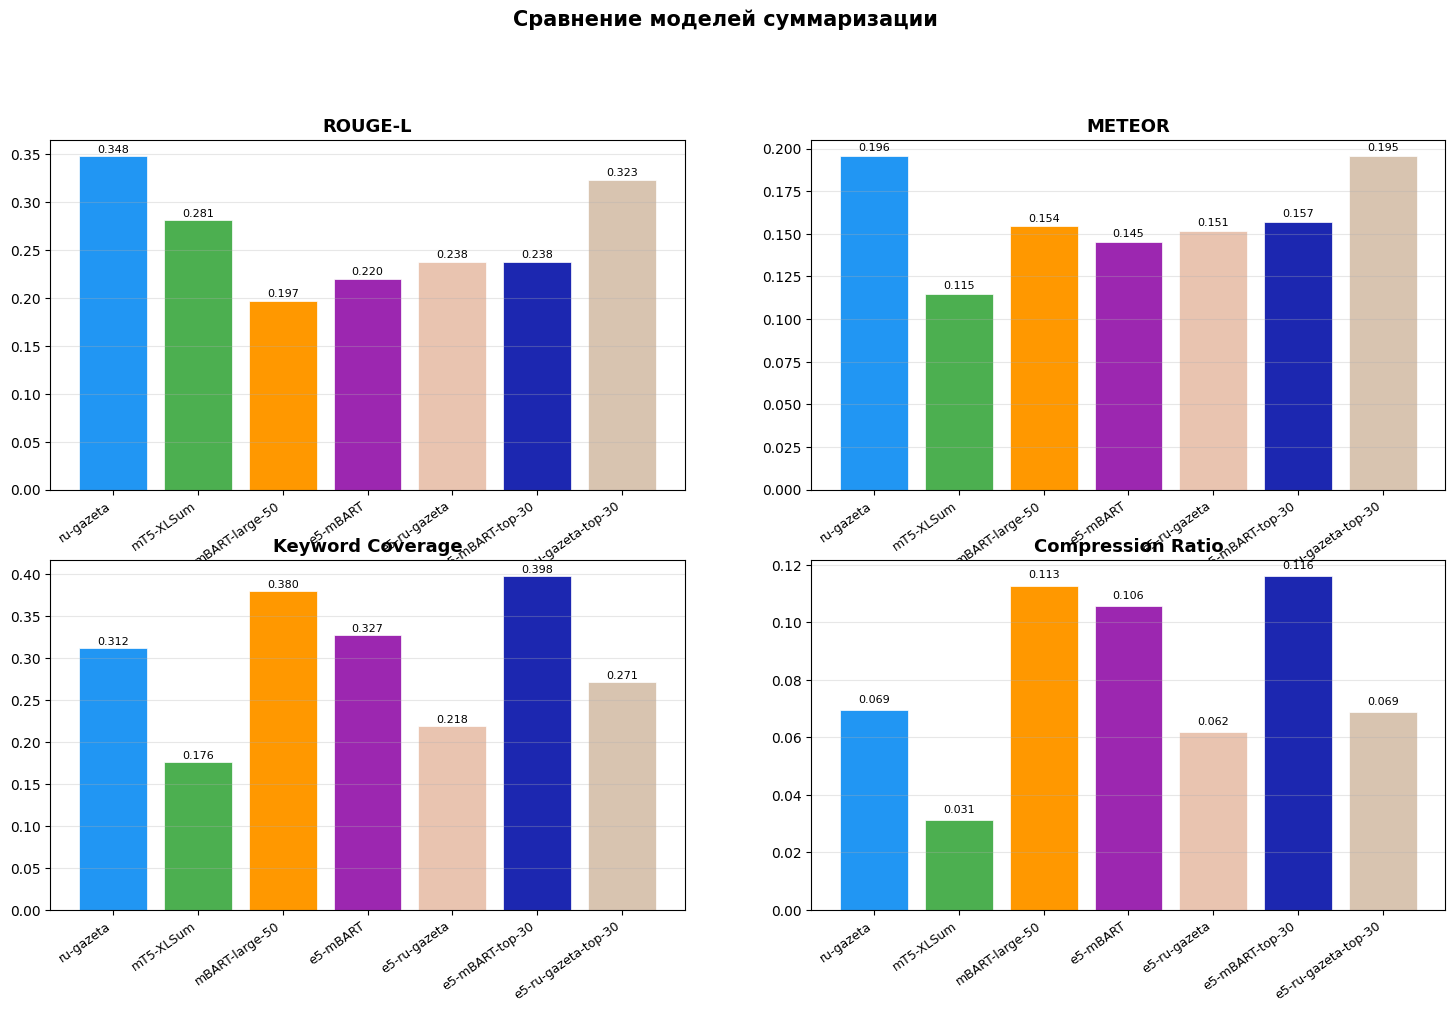

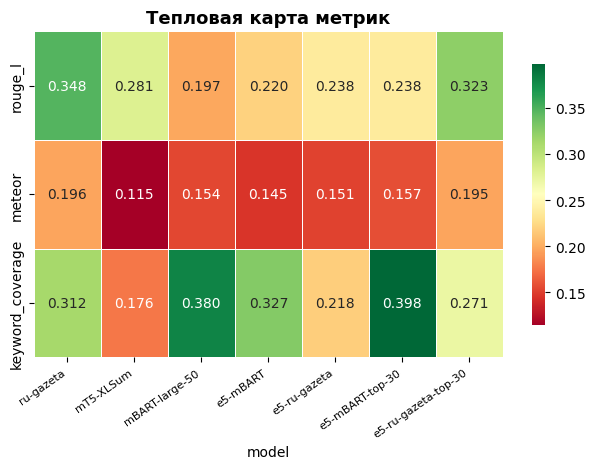

In [65]:
# Визуализация — radar chart и bar plots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

colors = {
    'ru-gazeta':       '#2196F3',
    'mT5-XLSum':         '#4CAF50',
    'mBART-large-50':    '#FF9800',
    'e5-mBART':     '#9C27B0',
    'e5-ru-gazeta': '#E9C4B0',
    'e5-mBART-top-30':     '#1C27B0',
    'e5-ru-gazeta-top-30': '#D8C4B0',
}

metric_labels = {
    'rouge_l':           'ROUGE-L',
    'meteor':            'METEOR',
    'keyword_coverage':  'Keyword Coverage',
    'compression_ratio': 'Compression Ratio',
}

for i, metric in enumerate(METRICS):
    ax = axes[i]
    vals   = results[metric]
    models = vals.index.tolist()
    bar_colors = [colors[m] for m in models]

    bars = ax.bar(range(len(models)), vals.values, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(metric_labels[metric], fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=35, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        
plt.suptitle('Сравнение моделей суммаризации', fontsize=15, fontweight='bold', y=1.01)
plt.show()

# сводная тепловая карта
ax = plt.axes()
metric_cols = [m for m in METRICS if m != 'compression_ratio']  # ratio отдельно
heatmap_data = results[metric_cols].T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Тепловая карта метрик', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Качественный анализ — примеры саммари

In [66]:
def show_examples(idx: int):
    """Показывает саммари всех моделей для одной статьи."""
    print(f"СТАТЬЯ #{idx}")
    print(f"Заголовок : {titles[idx]}")
    print(f"Keywords  : {', '.join(keywords[idx][:8])}")
    print(f"Длина     : {len(texts[idx])} символов")
    print(f"ОРИГИНАЛ (первые 300 символов):\n{texts[idx][:300]}...")
    print()

    for model_name, summaries in model_summaries.items():
        mtype = "[GEN]" if model_name in ['ru-gazeta', 'mT5-XLSum', 'mBART-large-50'] else "[EXT]"
        print(f"--- {mtype} {model_name} ---")
        print(summaries[idx])
        print()

# 3 примера: короткий, средний, длинный
short_idx  = sample['text_len'].idxmin()
medium_idx = (sample['text_len'] - sample['text_len'].median()).abs().idxmin()
long_idx   = sample['text_len'].idxmax()

for idx in [short_idx, medium_idx, long_idx]:
    show_examples(sample.index.get_loc(idx) if idx in sample.index else 0)

СТАТЬЯ #1
Заголовок : Стартовал прием заявок на «Цифровой Прорыв 2020» / Хабр
Keywords  : цифровой прорыв, хакатон
Длина     : 428 символов
ОРИГИНАЛ (первые 300 символов):
Мы рады объявить о запуске второго сезона конкурса "Цифровой прорыв"!В новом сезоне участников ждут хакатоны в 8 региональных хабах, еще больше экспертов, интересных кейсов и возможностей для самореализации, а в начале мая состоится крупнейший IT-марафон.Пришло время собирать команду и регистрироват...

--- [GEN] ru-gazeta ---
Начался второй сезон конкурса «Цифровой прорыв» — твой шанс заявить о себе и стать частью цифрового будущего.

--- [GEN] mT5-XLSum ---
Конкурс "Цифровой прорыв" в этом году начнется в сентябре, сообщили в пресс-службе ведомства.

--- [GEN] mBART-large-50 ---
Мы рады объявить о запуске второго сезона конкурса "Цифровой прорыв"!В новом сезоне участников ждут хакатоны в 8 региональных хабах, еще больше экспертов, интересных кейсов и возможностей для самореализации, а в начале мая состоится крупней

## 8. Анализ по длине текста
Проверяем, как меняется качество в зависимости от длины исходной статьи.

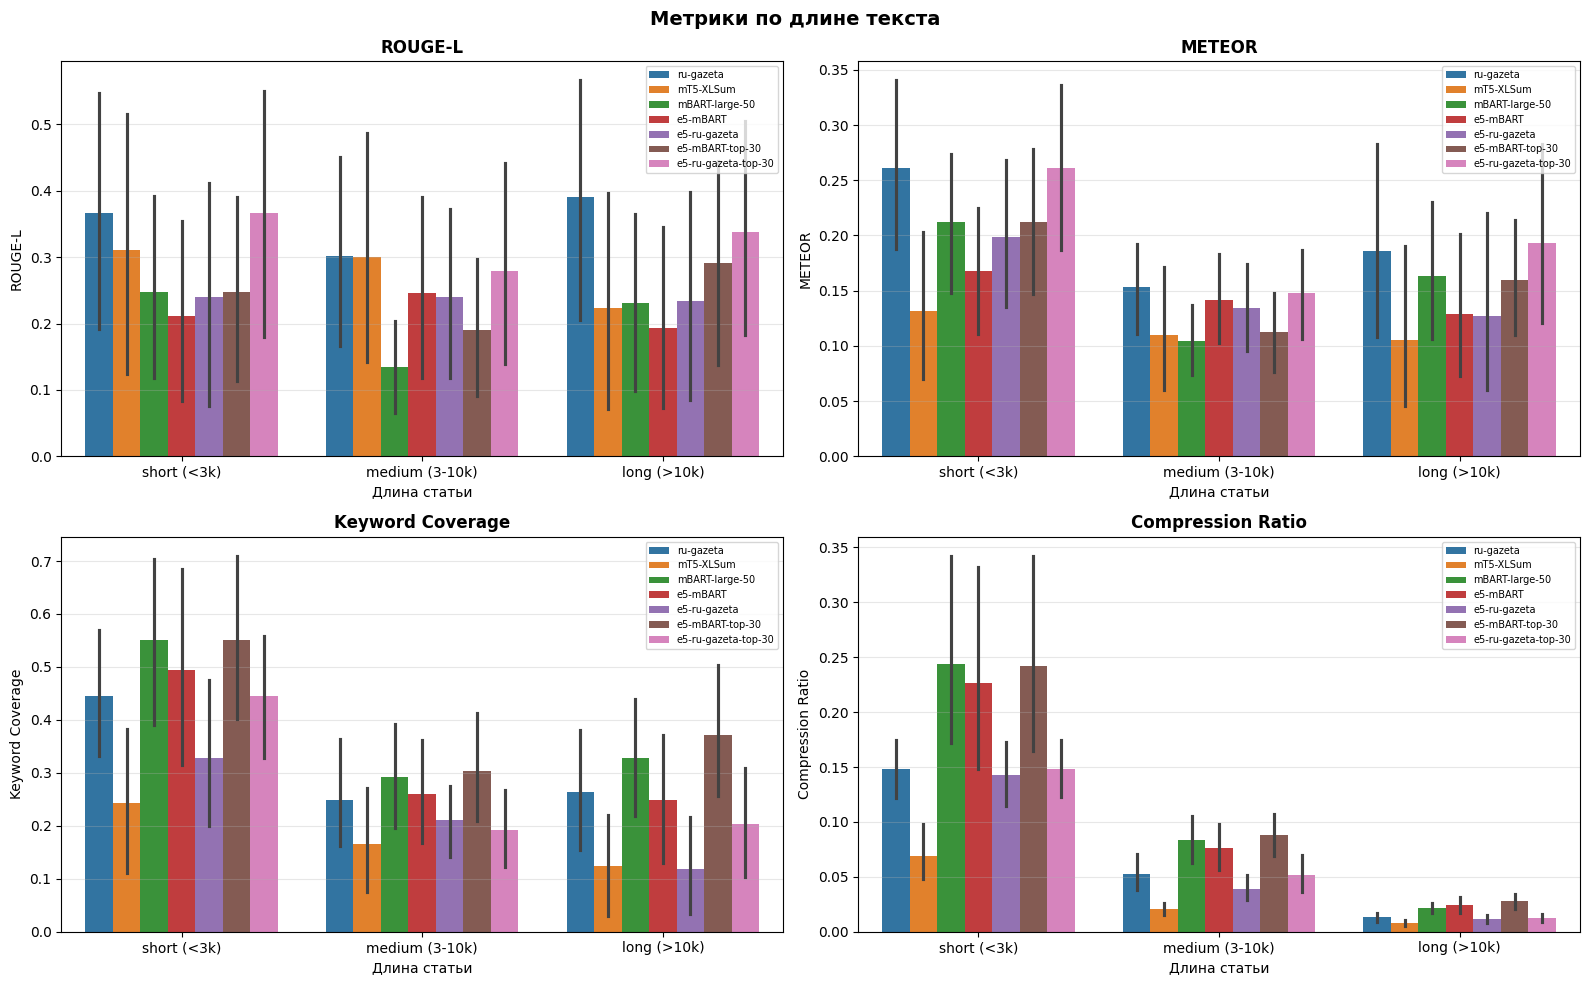

In [69]:
METRICS = ['rouge_l', 'meteor', 'keyword_coverage', 'compression_ratio']

text_lens = sample['text_len'].values
len_bins  = pd.cut(text_lens, bins=[0, 3000, 10000, float('inf')],
                   labels=['short (<3k)', 'medium (3-10k)', 'long (>10k)'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS):
    plot_data = []
    for model_name, df in all_metrics.items():
        for val, length_bin in zip(df[metric], len_bins):
            plot_data.append({'model': model_name, 'metric': val, 'length': str(length_bin)})

    plot_df = pd.DataFrame(plot_data)
    sns.barplot(data=plot_df, x='length', y='metric', hue='model', ax=ax)
    ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
    ax.set_xlabel('Длина статьи')
    ax.set_ylabel(metric_labels[metric])
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Метрики по длине текста', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Финальные выводы

In [70]:
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")

# Нормализуем метрики (кроме compression_ratio) и считаем общий скор
score_metrics = ['rouge_l', 'meteor', 'keyword_coverage']
norm = results[score_metrics].copy()
norm = (norm - norm.min()) / (norm.max() - norm.min() + 1e-9)
results['overall_score'] = norm.mean(axis=1)

print(results[['type'] + score_metrics + ['compression_ratio', 'overall_score']]
      .sort_values('overall_score', ascending=False)
      .to_string())

print()
best = results['overall_score'].idxmax()
print(f"Лучшая модель по совокупности метрик: {best}")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
                           type  rouge_l  meteor  keyword_coverage  compression_ratio  overall_score
model                                                                                               
ru-gazeta            generative   0.3476  0.1955            0.3121             0.0694       0.871448
e5-ru-gazeta-top-30  extractive   0.3231  0.1954            0.2712             0.0688       0.755277
e5-mBART-top-30      extractive   0.2378  0.1567            0.3976             0.1161       0.596745
mBART-large-50       generative   0.1971  0.1543            0.3802             0.1128       0.470538
e5-mBART             extractive   0.2197  0.1454            0.3274             0.1056       0.404491
e5-ru-gazeta         extractive   0.2378  0.1515            0.2184             0.0619       0.305859
mT5-XLSum            generative   0.2807  0.1147            0.1759             0.0312       0.185161

Лучшая модель по совокупности метрик: ru-gazeta
